Loading the Data: We use pandas to read the CSV file. The first column represents the labels, and the remaining 784 columns represent the pixel values of the 28x28 images.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Preprocessing: Standardizing the data ensures that each feature contributes equally to the analysis.

In [3]:
# Load the dataset
data = pd.read_csv('mnist-1.csv', header=None)

# Separate labels and features
labels = data.iloc[:, 0]
features = data.iloc[:, 1:]


In [4]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Applying PCA: We initialize PCA to reduce the data to 10 principal components. The fit_transform method computes the principal components and applies the dimensionality reduction.

In [6]:
# Initialize PCA with 10 components
pca = PCA(n_components=10)

# Fit PCA on the scaled data
principal_components = pca.fit_transform(scaled_features)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(10)])

Covariance Matrix: The covariance matrix of the transformed data helps in understanding how the principal components vary with respect to each other. Since PCA transforms the data to be uncorrelated, the off-diagonal elements of the covariance matrix should be close to zero.

In [7]:
# Compute the covariance matrix
cov_matrix = np.cov(principal_components, rowvar=False)

# Convert to DataFrame for better readability
cov_matrix_df = pd.DataFrame(cov_matrix, 
                             columns=[f'PC{i+1}' for i in range(10)], 
                             index=[f'PC{i+1}' for i in range(10)])

print("Covariance Matrix of the Transformed Data:")
print(cov_matrix_df)

Covariance Matrix of the Transformed Data:
               PC1           PC2           PC3           PC4           PC5  \
PC1   4.073189e+01  3.614897e-14  6.751281e-16  2.008802e-15 -2.274116e-16   
PC2   3.614897e-14  3.028703e+01 -9.096463e-15 -8.741133e-15 -5.685289e-17   
PC3   6.751281e-16 -9.096463e-15  2.735512e+01 -1.551136e-14  2.520478e-15   
PC4   2.008802e-15 -8.741133e-15 -1.551136e-14  2.113710e+01 -7.983094e-15   
PC5  -2.274116e-16 -5.685289e-17  2.520478e-15 -7.983094e-15  1.824404e+01   
PC6  -4.548232e-16  7.201367e-16  1.639258e-15 -5.656863e-15 -1.023352e-15   
PC7   1.262608e-15  3.979703e-16  1.544504e-15  1.305248e-15 -5.983767e-15   
PC8   8.338425e-16 -3.790193e-17 -2.688668e-16 -1.681306e-15  6.111686e-15   
PC9  -2.913711e-16  1.670054e-16  1.326568e-15 -9.759747e-16 -4.808807e-15   
PC10 -2.179361e-16 -1.972085e-16 -8.527934e-17 -3.979703e-16  1.103894e-15   

               PC6           PC7           PC8           PC9          PC10  
PC1  -4.548232e-16  1

Visualization: A heatmap provides a visual representation of the covariance matrix, making it easier to interpret the relationships between principal components.

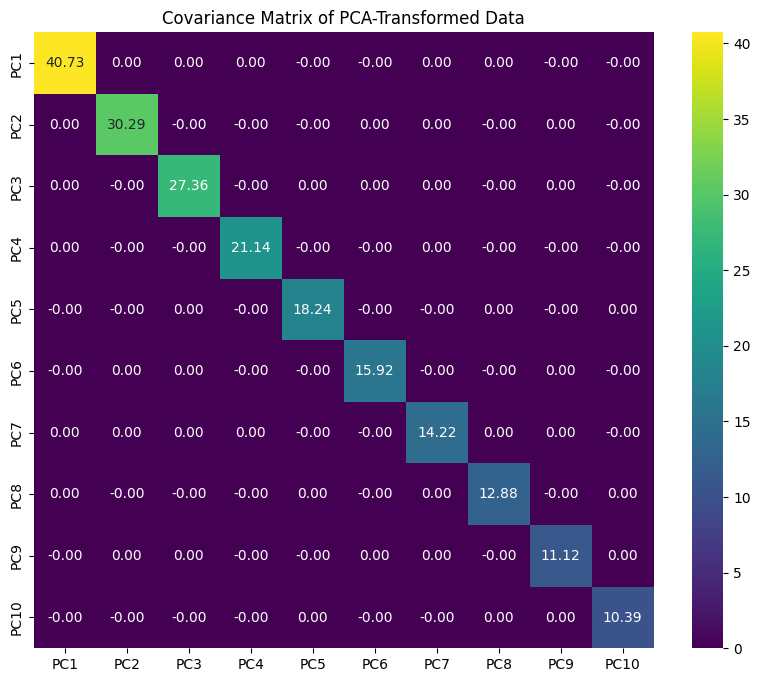

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix_df, annot=True, fmt=".2f", cmap='viridis')
plt.title('Covariance Matrix of PCA-Transformed Data')
plt.show()

You might also want to look at the explained variance to understand how much information (variance) is retained by the principal components.

In [9]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance by each Principal Component:")
print(explained_variance)


Explained Variance by each Principal Component:
[0.06133298 0.0456054  0.0411906  0.03182768 0.02747139 0.02397757
 0.02141587 0.01938774 0.01673765 0.01564331]


If you need to use the transformed data for further analysis or modeling, you can save it to a new CSV file.

In [10]:
pca_df.to_csv('mnist_pca_10d.csv', index=False)


In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Load the dataset
data = pd.read_csv('mnist-1.csv', header=None)

# Separate labels and features
labels = data.iloc[:, 0]        # First column is the label
features = data.iloc[:, 1:]      # Remaining columns are pixel values


The feature data is standardized using StandardScaler to ensure that each feature has a mean of 0 and a standard deviation of 1. This step is crucial for K-Means clustering as it relies on distance calculations.

In [15]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
scaled_features = scaler.fit_transform(features)


The K-Means algorithm is initialized with 10 clusters (since there are 10 digits) and fitted to the scaled data. The cluster labels for each sample are retrieved.

In [16]:
# Define the number of clusters
num_clusters = 10

# Initialize KMeans with the desired number of clusters and random state for reproducibility
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

# Fit KMeans on the scaled data
kmeans.fit(scaled_features)

# Retrieve the cluster labels for each sample
cluster_labels = kmeans.labels_

# (Optional) Retrieve the cluster centers
cluster_centers = kmeans.cluster_centers_

/home/chalyn03/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


A comparison between the actual labels and the cluster labels is created to analyze how well the clustering aligns with the true digit labels.

In [17]:
# Create a DataFrame to compare actual labels with cluster labels
comparison_df = pd.DataFrame({'Actual Label': labels, 'Cluster Label': cluster_labels})

# Display the first few rows
print(comparison_df.head())

   Actual Label  Cluster Label
0           5.0              0
1           0.0              3
2           4.0              4
3           1.0              2
4           9.0              7


A count plot is generated to visualize the distribution of actual labels within each cluster. This helps in understanding the clustering performance visually.

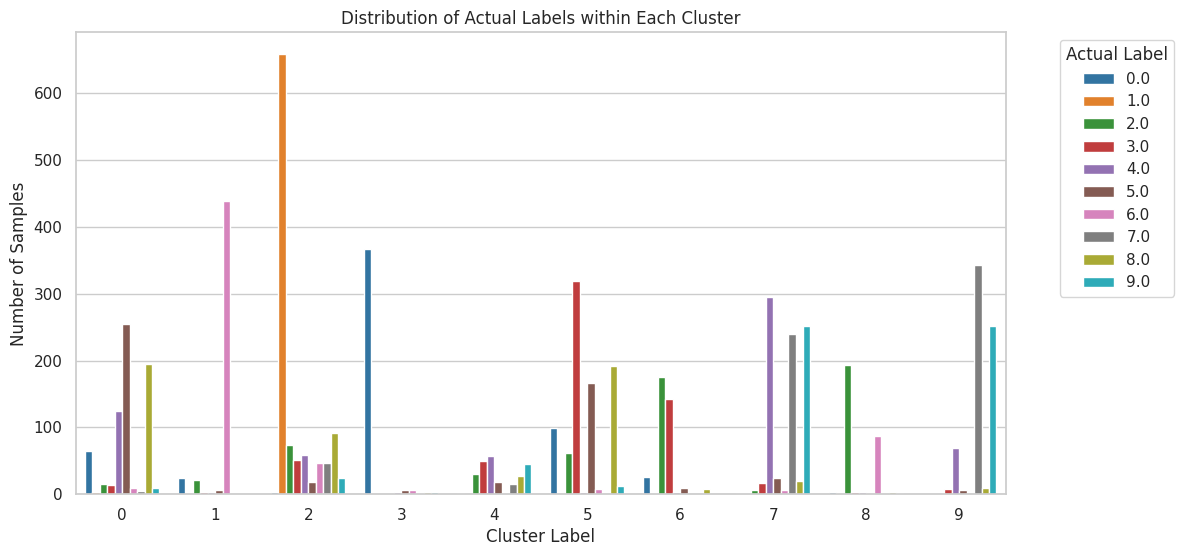

In [18]:
# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a count plot
plt.figure(figsize=(12, 6))
sns.countplot(x='Cluster Label', hue='Actual Label', data=comparison_df, palette='tab10')
plt.title('Distribution of Actual Labels within Each Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Samples')
plt.legend(title='Actual Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Metrics like Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) are calculated to quantitatively assess the clustering performance. These metrics compare the similarity between the actual labels and the cluster assignments.

In [19]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate Adjusted Rand Index
ari = adjusted_rand_score(labels, cluster_labels)
print(f'Adjusted Rand Index (ARI): {ari:.4f}')

# Calculate Normalized Mutual Information
nmi = normalized_mutual_info_score(labels, cluster_labels)
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')

Adjusted Rand Index (ARI): 0.3280
Normalized Mutual Information (NMI): 0.4517


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin

In [22]:
# Load the dataset
data = pd.read_csv('mnist-1.csv', header=None)

# Separate labels and features
labels = data.iloc[:, 0].values        # Shape: (6000,)
features = data.iloc[:, 1:].values     # Shape: (6000, 784)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [23]:
class CustomKMeans:
    def __init__(self, n_clusters=10, max_iters=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.inertia_history = []
        self.labels_ = None

    def initialize_centroids(self, X):
        np.random.seed(self.random_state)
        initial_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[initial_indices]

    def fit(self, X):
        self.initialize_centroids(X)
        
        for i in range(self.max_iters):
            # Assign clusters
            labels = pairwise_distances_argmin(X, self.centroids)
            
            # Compute inertia
            inertia = np.sum((X - self.centroids[labels]) ** 2)
            self.inertia_history.append(inertia)
            
            # Compute new centroids
            new_centroids = np.array([X[labels == j].mean(axis=0) if len(X[labels == j]) > 0 else self.centroids[j] 
                                      for j in range(self.n_clusters)])
            
            # Check for convergence
            shift = np.linalg.norm(self.centroids - new_centroids)
            print(f'Iteration {i+1}, Inertia: {inertia:.4f}, Centroid Shift: {shift:.6f}')
            if shift <= self.tol:
                print("Convergence reached!")
                break
            
            self.centroids = new_centroids
        
        self.labels_ = labels

    def predict(self, X):
        return pairwise_distances_argmin(X, self.centroids)


In [29]:
# Initialize CustomKMeans
custom_kmeans = CustomKMeans(n_clusters=10, max_iters=300, tol=1e-4, random_state=42)

# Fit the model to the data
custom_kmeans.fit(scaled_features)

# Retrieve the inertia history
inertia_history = custom_kmeans.inertia_history

# Retrieve cluster labels
cluster_labels = custom_kmeans.labels_

Iteration 1, Inertia: 4704991.2462, Centroid Shift: 52.745420
Iteration 2, Inertia: 3547153.5730, Centroid Shift: 17.196175
Iteration 3, Inertia: 3478463.7524, Centroid Shift: 12.319865
Iteration 4, Inertia: 3432847.5626, Centroid Shift: 8.611278
Iteration 5, Inertia: 3396624.8168, Centroid Shift: 6.006177
Iteration 6, Inertia: 3369352.8500, Centroid Shift: 4.328701
Iteration 7, Inertia: 3354850.3613, Centroid Shift: 3.317556
Iteration 8, Inertia: 3347370.6540, Centroid Shift: 2.407350
Iteration 9, Inertia: 3343919.0766, Centroid Shift: 1.685631
Iteration 10, Inertia: 3342428.3644, Centroid Shift: 1.466861
Iteration 11, Inertia: 3341421.7108, Centroid Shift: 1.705734
Iteration 12, Inertia: 3340357.0360, Centroid Shift: 1.657229
Iteration 13, Inertia: 3339275.8023, Centroid Shift: 1.572610
Iteration 14, Inertia: 3338242.8042, Centroid Shift: 1.361859
Iteration 15, Inertia: 3337143.3802, Centroid Shift: 1.816964
Iteration 16, Inertia: 3335439.0649, Centroid Shift: 1.626716
Iteration 17, 

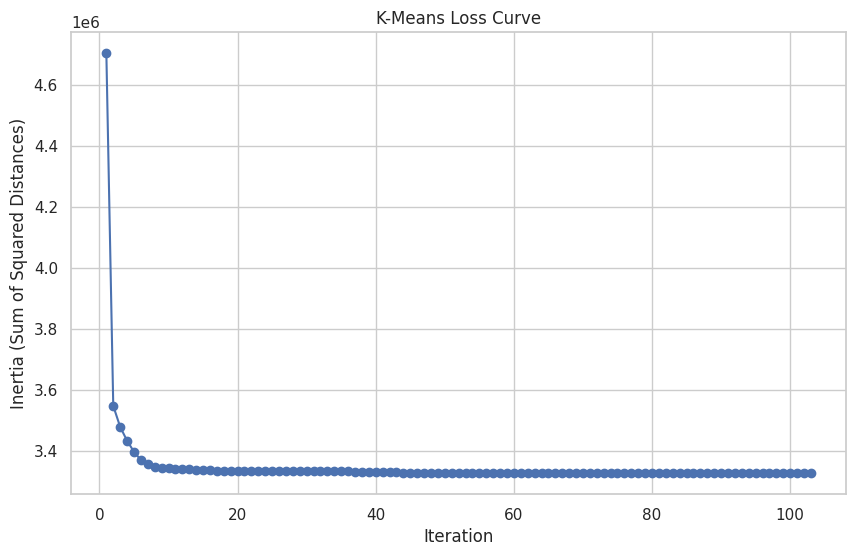

In [30]:
# Plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(inertia_history) + 1), inertia_history, marker='o')
plt.title('K-Means Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()

In [31]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate Adjusted Rand Index
ari = adjusted_rand_score(labels, cluster_labels)
print(f'Adjusted Rand Index (ARI): {ari:.4f}')

# Calculate Normalized Mutual Information
nmi = normalized_mutual_info_score(labels, cluster_labels)
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')


Adjusted Rand Index (ARI): 0.3171
Normalized Mutual Information (NMI): 0.4468


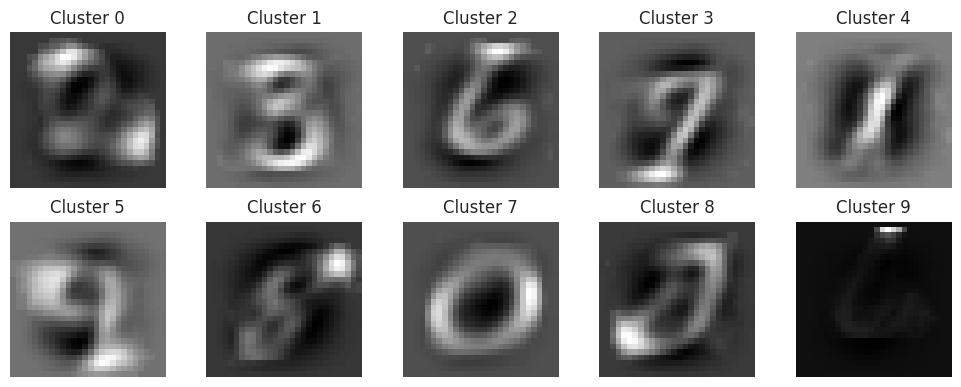

In [32]:
# Function to plot cluster centers as images
def plot_cluster_centers(centroids, n_cols=5):
    n_clusters = centroids.shape[0]
    n_rows = n_clusters // n_cols + int(n_clusters % n_cols != 0)
    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_clusters):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(centroids[i].reshape(28, 28), cmap='gray')
        plt.title(f'Cluster {i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot the cluster centers
plot_cluster_centers(custom_kmeans.centroids)

In [33]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
RANDOM_STATE = 42

# Configure matplotlib
%matplotlib inline
sns.set(style="whitegrid")


In [34]:
# Load the dataset
data = pd.read_csv('mnist-1.csv', header=None)

# Separate labels and features
labels = data.iloc[:, 0].values        # Shape: (6000,)
features = data.iloc[:, 1:].values     # Shape: (6000, 784)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [35]:
# Define the split index
train_size = 4000
validation_size = 2000

# Split the data
X_train = scaled_features[:train_size]
X_validation = scaled_features[train_size:train_size + validation_size]

y_train = labels[:train_size]
y_validation = labels[train_size:train_size + validation_size]

print(f'Training Set Shape: {X_train.shape}')
print(f'Validation Set Shape: {X_validation.shape}')

Training Set Shape: (4000, 784)
Validation Set Shape: (2000, 784)


In [36]:
# Define the range of k values
k_values = range(2, 16)

In [37]:
# Initialize lists to store metrics
inertia_train = []
inertia_validation = []
silhouette_train = []
silhouette_validation = []

for k in k_values:
    print(f'Fitting K-Means for k={k}')
    
    # Initialize KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    
    # Fit on training data
    kmeans.fit(X_train)
    
    # Inertia on training data
    inertia_train.append(kmeans.inertia_)
    
    # Predict cluster labels for validation data
    validation_labels = kmeans.predict(X_validation)
    
    # Calculate inertia on validation data
    inertia_validation.append(
        np.sum((X_validation - kmeans.cluster_centers_[validation_labels]) ** 2)
    )
    
    # Calculate Silhouette Score on training data
    silhouette_train.append(silhouette_score(X_train, kmeans.labels_))
    
    # Calculate Silhouette Score on validation data
    silhouette_validation.append(silhouette_score(X_validation, validation_labels))

Fitting K-Means for k=2
Fitting K-Means for k=3
Fitting K-Means for k=4
Fitting K-Means for k=5
Fitting K-Means for k=6
Fitting K-Means for k=7
Fitting K-Means for k=8
Fitting K-Means for k=9
Fitting K-Means for k=10
Fitting K-Means for k=11
Fitting K-Means for k=12
Fitting K-Means for k=13
Fitting K-Means for k=14
Fitting K-Means for k=15


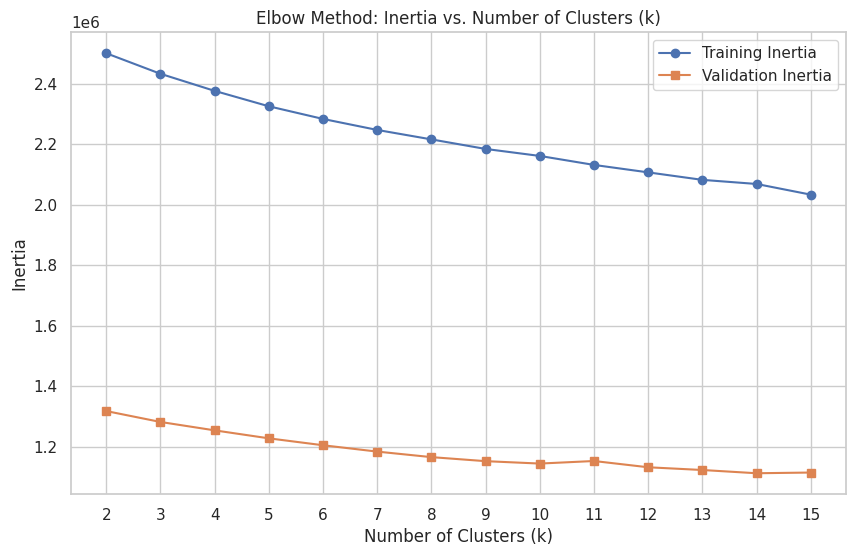

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_train, marker='o', label='Training Inertia')
plt.plot(k_values, inertia_validation, marker='s', label='Validation Inertia')
plt.title('Elbow Method: Inertia vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.legend()
plt.show()

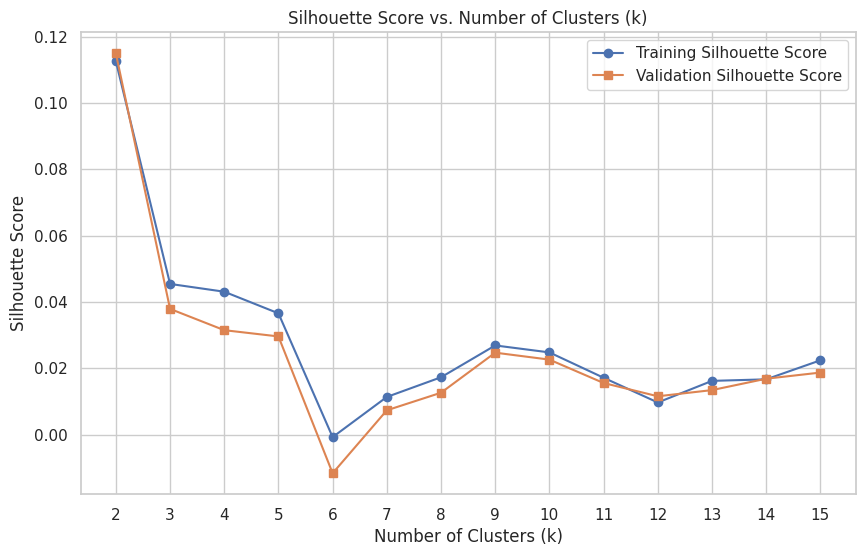

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_train, marker='o', label='Training Silhouette Score')
plt.plot(k_values, silhouette_validation, marker='s', label='Validation Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.legend()
plt.show()

In [40]:
# Define the optimal k (e.g., k=10)
optimal_k = 10

# Initialize KMeans with optimal k
kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=RANDOM_STATE, n_init=10)

# Fit on training data
kmeans_optimal.fit(X_train)

# Predict cluster labels for training and validation sets
train_labels_optimal = kmeans_optimal.labels_
validation_labels_optimal = kmeans_optimal.predict(X_validation)

# Calculate final metrics
final_inertia_train = kmeans_optimal.inertia_
final_inertia_validation = np.sum((X_validation - kmeans_optimal.cluster_centers_[validation_labels_optimal]) ** 2)

final_silhouette_train = silhouette_score(X_train, train_labels_optimal)
final_silhouette_validation = silhouette_score(X_validation, validation_labels_optimal)

print(f'Optimal k: {optimal_k}')
print(f'Training Inertia: {final_inertia_train:.2f}')
print(f'Validation Inertia: {final_inertia_validation:.2f}')
print(f'Training Silhouette Score: {final_silhouette_train:.4f}')
print(f'Validation Silhouette Score: {final_silhouette_validation:.4f}')

Optimal k: 10
Training Inertia: 2161420.31
Validation Inertia: 1144687.16
Training Silhouette Score: 0.0248
Validation Silhouette Score: 0.0226


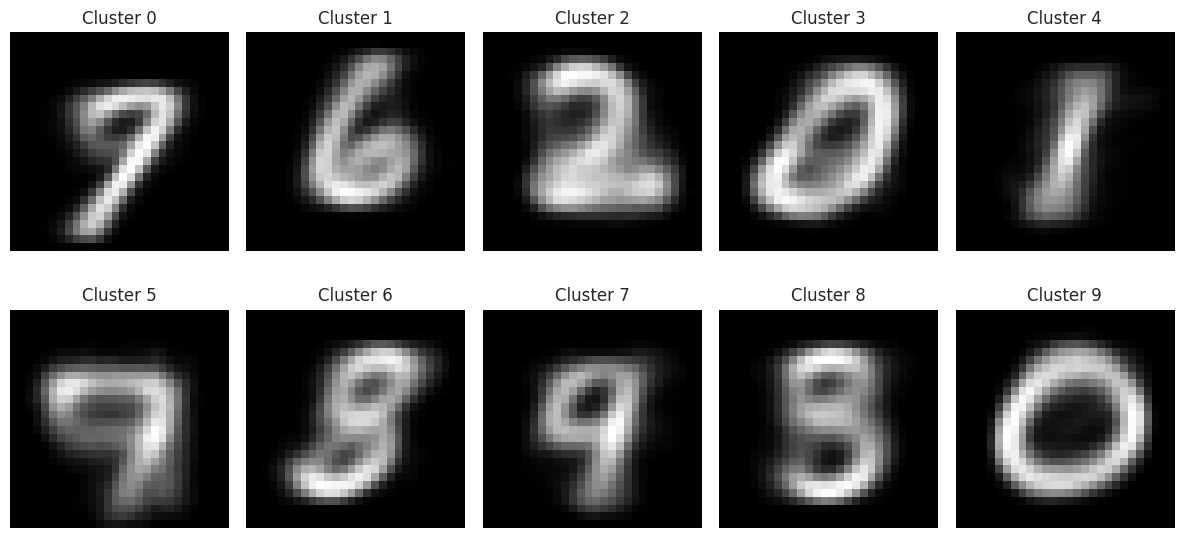

In [41]:
def plot_cluster_centers(centroids, scaler, n_clusters=10):
    """
    Plots the cluster centers as images.
    
    Parameters:
    - centroids: Array of cluster centers.
    - scaler: The StandardScaler object used for scaling.
    - n_clusters: Number of clusters.
    """
    # Inverse transform to original scale
    original_centroids = scaler.inverse_transform(centroids)
    
    plt.figure(figsize=(12, 6))
    for i in range(n_clusters):
        plt.subplot(2, 5, i + 1)
        plt.imshow(original_centroids[i].reshape(28, 28), cmap='gray')
        plt.title(f'Cluster {i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot the cluster centers
plot_cluster_centers(kmeans_optimal.cluster_centers_, scaler, n_clusters=optimal_k)

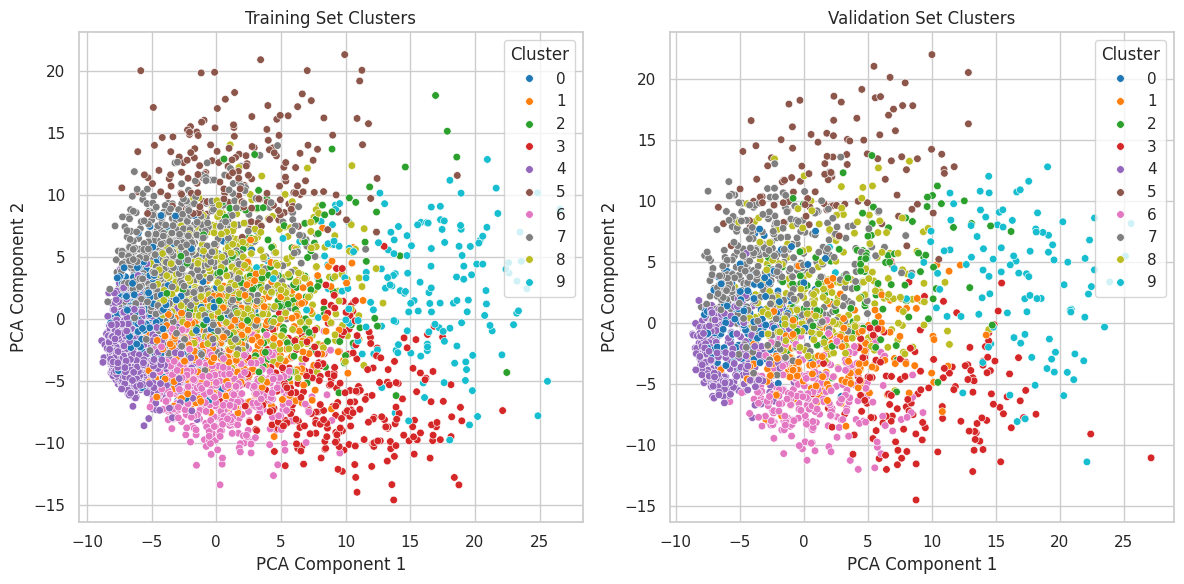

In [42]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions for visualization
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca_vis.fit_transform(X_train)
X_validation_pca = pca_vis.transform(X_validation)

# Plot training data clusters
plt.figure(figsize=(12, 6))

# Training Set
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=train_labels_optimal, palette='tab10', legend='full', s=30)
plt.title('Training Set Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')

# Validation Set
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_validation_pca[:, 0], y=X_validation_pca[:, 1], hue=validation_labels_optimal, palette='tab10', legend='full', s=30)
plt.title('Validation Set Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [43]:
# Cell 1: Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better visuals
%matplotlib inline
sns.set(style="whitegrid")

In [45]:
# Cell 2: Load and Preprocess the Dataset

# Load the first 500 samples from mnist.csv
# Ensure 'mnist.csv' is in the current directory
data = pd.read_csv('mnist-1.csv', header=None)
X = data.iloc[:500, 1:].values  # First 500 samples, excluding labels

# Optional: Extract labels if needed for evaluation
y_true = data.iloc[:500, 0].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape of standardized data: {X_scaled.shape}')


Shape of standardized data: (500, 784)


In [46]:
# Cell 3: Compute the RBF Kernel Matrix

# Number of samples
N = X_scaled.shape[0]

# Compute the pairwise squared Euclidean distances efficiently
sum_X = np.sum(np.square(X_scaled), axis=1)
dist_matrix = -2 * np.dot(X_scaled, X_scaled.T) + sum_X[:, np.newaxis] + sum_X[np.newaxis, :]

# Compute sigma^2 as per the given formula:
# 2σ² = (1/N²) * sum_{i=1}^N sum_{j=1}^N ||x_i -x_j||²
sigma_squared = np.sum(dist_matrix) / (2 * N**2)

print(f'Computed sigma^2: {sigma_squared:.4f}')

# Compute the RBF Kernel Matrix
K = np.exp(-dist_matrix / (2 * sigma_squared))

# Verify the shape of the kernel matrix
print(f'Shape of Kernel Matrix K: {K.shape}')

Computed sigma^2: 579.0000
Shape of Kernel Matrix K: (500, 500)


In [47]:
# Cell 4: Initialize Cluster Assignments

# Number of clusters
K_clusters = 5

# Random initial assignments
clusters = np.random.choice(K_clusters, N)

# Display initial cluster assignments
print(f'Initial cluster assignments:\n{clusters}')


Initial cluster assignments:
[3 4 2 4 4 1 2 2 2 4 3 2 4 1 3 1 3 4 0 3 1 4 3 0 0 2 2 1 3 3 2 3 3 0 2 4 2
 4 0 1 3 0 3 1 1 0 1 4 1 3 3 3 3 4 2 0 3 1 3 1 1 3 4 1 1 3 1 1 3 3 0 4 4 1
 4 1 0 3 3 3 4 0 4 4 0 0 0 0 3 2 2 0 2 2 0 2 4 1 1 0 3 0 3 1 0 4 2 3 2 2 0
 2 4 2 0 4 1 2 0 1 1 3 4 2 0 3 4 3 4 4 2 4 3 4 2 2 3 1 1 4 0 4 3 3 3 3 3 2
 1 3 0 0 0 0 2 0 3 4 0 2 2 0 4 0 2 1 3 2 0 3 0 0 1 3 3 1 2 0 4 0 0 2 0 1 1
 3 4 0 0 2 1 4 3 1 3 2 2 0 4 3 1 2 0 0 3 2 4 2 3 3 2 3 2 1 2 2 3 3 0 0 1 0
 2 3 0 0 1 1 2 3 1 0 3 3 0 1 0 3 4 4 2 0 0 2 2 2 3 0 3 2 0 3 3 2 0 2 0 4 1
 1 1 2 4 0 3 0 3 0 4 3 2 0 0 3 2 2 4 2 2 2 1 4 0 3 0 4 3 4 2 3 2 0 0 3 3 4
 4 2 3 0 4 4 0 4 2 3 0 3 4 4 0 2 1 0 1 1 2 1 1 2 1 1 1 0 0 0 2 4 1 1 2 1 0
 4 3 1 0 3 4 3 0 3 2 3 1 1 2 0 1 4 1 1 0 3 1 2 3 4 0 4 3 3 3 4 3 4 3 2 3 4
 1 3 1 2 0 2 3 1 1 4 1 4 0 3 4 0 1 1 0 1 0 4 4 0 4 4 4 2 3 1 2 4 0 4 3 4 0
 3 4 3 1 1 4 3 0 4 1 1 4 3 1 3 1 1 2 1 0 4 4 3 1 0 3 2 3 3 1 2 3 0 0 4 2 2
 4 3 2 0 0 1 2 3 4 4 3 1 4 2 1 2 0 1 4 1 1 1 1 2 0 3 1 4 1 4 2 4 3 0 4 

In [48]:
# Cell 5: Define a Function to Compute Distances in Kernel Space

def compute_distances(K, clusters, K_clusters):
    """
    Compute the distance of each point to each cluster in the kernel space.
    
    Parameters:
    - K: Kernel matrix (N x N)
    - clusters: Current cluster assignments (N,)
    - K_clusters: Number of clusters
    
    Returns:
    - distances: A (N x K_clusters) matrix of distances
    """
    distances = np.zeros((N, K_clusters))
    
    for c in range(K_clusters):
        # Indices of points in cluster c
        members = np.where(clusters == c)[0]
        n_c = len(members)
        
        if n_c == 0:
            # Avoid division by zero; assign infinite distance
            distances[:, c] = np.inf
            continue
        
        # Compute sums required for distance calculation
        sum_K_c = np.sum(K[:, members], axis=1)  # Sum over K(x_i, x_j) for j in cluster c
        sum_K_cc = np.sum(K[np.ix_(members, members)])  # Sum over all K(x_i, x_j) in cluster c
        
        # Distance formula in kernel space
        distances[:, c] = K.diagonal() - (2 / n_c) * sum_K_c + (1 / (n_c**2)) * sum_K_cc
    
    return distances

In [49]:
# Cell 6: Kernel K-Means Iterative Optimization

# Maximum number of iterations
max_iterations = 100

for iteration in range(max_iterations):
    print(f'\nIteration {iteration + 1}')
    
    # Compute distances to each cluster
    distances = compute_distances(K, clusters, K_clusters)
    
    # Assign each point to the nearest cluster
    new_clusters = np.argmin(distances, axis=1)
    
    # Check for convergence
    if np.array_equal(clusters, new_clusters):
        print('Convergence reached!')
        break
    
    clusters = new_clusters

# Display final cluster assignments
print(f'\nFinal cluster assignments:\n{clusters}')


Iteration 1

Iteration 2

Iteration 3

Iteration 4

Iteration 5

Iteration 6

Iteration 7

Iteration 8

Iteration 9

Iteration 10

Iteration 11

Iteration 12

Iteration 13
Convergence reached!

Final cluster assignments:
[2 3 2 4 1 0 4 0 4 1 0 4 2 0 4 1 2 4 0 1 2 3 1 4 0 0 1 2 2 2 2 0 0 1 0 4 0
 0 1 0 4 0 1 1 4 1 1 2 0 0 0 3 2 4 1 1 3 1 1 4 2 4 0 3 0 4 0 4 3 0 4 2 4 0
 0 0 2 4 4 1 0 0 0 0 2 0 2 1 3 1 0 2 1 0 1 0 1 0 0 4 1 2 4 1 4 4 0 0 3 2 2
 2 4 4 3 1 1 2 0 3 2 3 2 2 4 0 0 2 4 0 0 1 4 1 2 2 0 4 0 1 1 2 1 1 4 4 0 0
 1 2 4 0 4 1 1 0 3 0 2 2 1 2 1 1 2 0 1 1 4 0 1 2 1 4 4 4 1 4 2 0 4 2 0 1 4
 2 0 2 1 2 0 4 0 1 1 1 2 4 2 1 4 4 2 0 0 4 3 0 4 3 0 4 1 2 2 0 0 1 0 0 2 0
 2 1 1 0 1 1 2 3 1 4 0 0 0 0 2 1 0 0 4 2 0 1 0 0 3 1 4 3 2 4 2 2 0 0 4 1 1
 2 3 0 0 1 1 0 2 1 1 4 4 1 1 2 0 1 4 2 0 0 1 2 2 3 2 1 0 4 1 1 4 0 1 3 2 0
 3 1 0 0 4 1 0 3 1 1 3 1 2 4 4 0 2 1 1 4 0 2 2 1 0 0 1 2 1 0 0 2 0 2 0 0 0
 0 1 0 1 1 1 2 0 2 1 0 1 4 1 2 0 1 1 4 0 1 1 4 0 4 4 3 2 0 1 1 1 0 4 0 4 1
 4 1 1 1 1 2 0 1 2 1 2 0 4 1

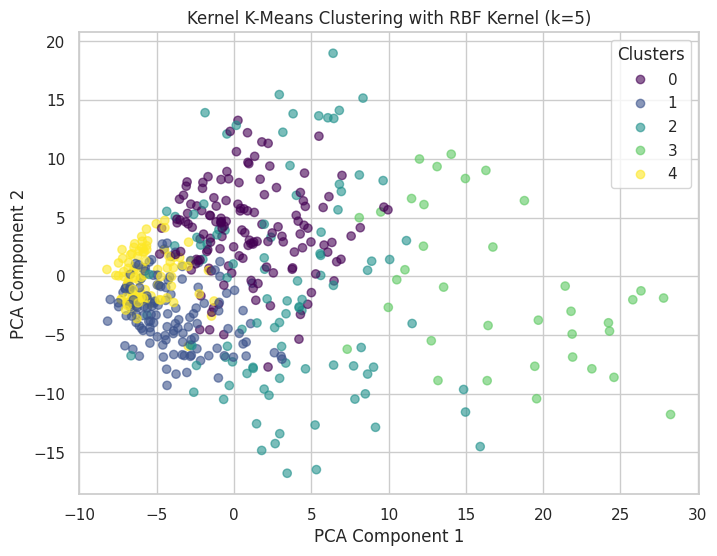

In [50]:
# Cell 7: Visualize the Clustering Results

# Reduce dimensions to 2 for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a scatter plot of the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('Kernel K-Means Clustering with RBF Kernel (k=5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.show()

In [51]:
# Cell 8: Evaluate Clustering Performance

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_true, clusters)

# Calculate Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(y_true, clusters)

print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')

Adjusted Rand Index (ARI): 0.2701
Normalized Mutual Information (NMI): 0.4077


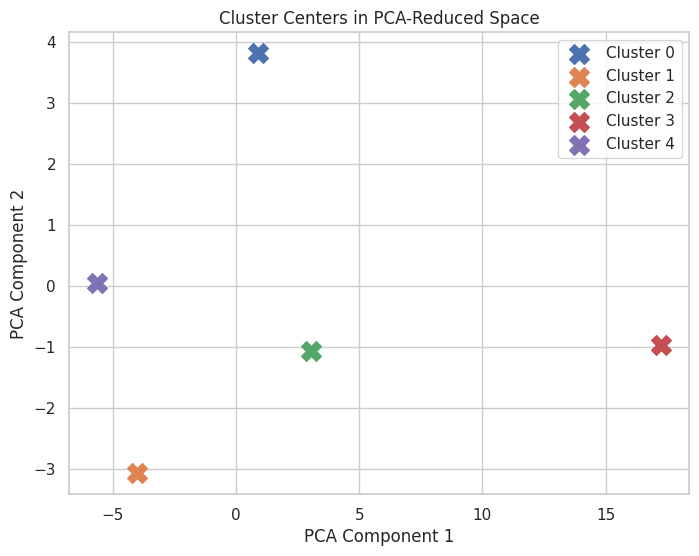

In [52]:
# Cell 9: (Optional) Visualize Cluster Centers

# Function to plot cluster centers
def plot_cluster_centers(X_pca, clusters, K_clusters):
    """
    Plots the cluster centers in the PCA-reduced space.
    
    Parameters:
    - X_pca: PCA-transformed data (N x 2)
    - clusters: Cluster assignments (N,)
    - K_clusters: Number of clusters
    """
    plt.figure(figsize=(8, 6))
    for c in range(K_clusters):
        # Extract points belonging to cluster c
        cluster_points = X_pca[clusters == c]
        if len(cluster_points) == 0:
            continue
        # Compute the centroid in PCA space
        centroid = cluster_points.mean(axis=0)
        # Plot the centroid
        plt.scatter(centroid[0], centroid[1], marker='X', s=200, label=f'Cluster {c}')
    
    plt.title('Cluster Centers in PCA-Reduced Space')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.show()

# Plot the cluster centers
plot_cluster_centers(X_pca, clusters, K_clusters)